# 2.1 Climate Unsupervised Learning

This script contains the following points:

#### 1. Import libraries & data

#### 2. Dendrograms for unscaled data

#### 3. Dendrograms for scaled data

In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import operator
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from matplotlib.pyplot import figure
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

In [21]:
#Create a path to data
path = r'/Users/chrismace/Desktop/7 Machine Learning'

In [32]:
df = pd.read_csv(os.path.join(path, 'Dataset-weather-prediction-dataset-processed.csv'))

In [33]:
df.head()

,DATE,MONTH,BASEL_cloud_cover,BASEL_wind_speed,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_snow_depth,BASEL_sunshine,...,VALENTIA_cloud_cover,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_snow_depth,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
0,19600101,1,7,2.1,0.85,1.018,0.32,0.09,0,0.7,...,5,0.88,1.0003,0.45,0.34,0,4.7,8.5,6.0,10.9
1,19600102,1,6,2.1,0.84,1.018,0.36,1.05,0,1.1,...,7,0.91,1.0007,0.25,0.84,0,0.7,8.9,5.6,12.1
2,19600103,1,8,2.1,0.90,1.018,0.18,0.30,0,0.0,...,7,0.91,1.0096,0.17,0.08,0,0.1,10.5,8.1,12.9
3,19600104,1,3,2.1,0.92,1.018,0.58,0.00,0,4.1,...,7,0.86,1.0184,0.13,0.98,0,0.0,7.4,7.3,10.6
4,19600105,1,6,2.1,0.95,1.018,0.65,0.14,0,5.4,...,3,0.80,1.0328,0.46,0.00,0,5.7,5.7,3.0,8.4


In [34]:
df.shape

(22950, 170)

In [51]:
df2 = pd.read_csv(os.path.join(path, 'climate_scaled.csv'), index_col=0)

In [52]:
df2.head()

,id,DATE,MONTH,BASEL_cloud_cover,BASEL_wind_speed,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_snow_depth,...,VALENTIA_cloud_cover,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_snow_depth,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
0,-1.731975,19600101,-1.599964,0.660514,-0.02793,0.826097,-0.001949,-1.101066,-0.265148,-0.179228,...,-0.443701,0.761754,-1.299744,-0.806427,-0.088407,-0.024706,0.372147,-0.668215,-0.519743,-0.752237
1,-1.731824,19600102,-1.599964,0.244897,-0.02793,0.735760,-0.001949,-1.058108,1.658760,-0.179228,...,0.783085,1.183580,-1.262455,-1.042055,0.503361,-0.024706,-0.829285,-0.548046,-0.629054,-0.407141
2,-1.731673,19600103,-1.599964,1.076130,-0.02793,1.277781,-0.001949,-1.251420,0.155707,-0.179228,...,0.783085,1.183580,-0.432779,-1.136306,-0.396127,-0.024706,-1.009500,-0.067372,0.054135,-0.177078
3,-1.731523,19600104,-1.599964,-1.001953,-0.02793,1.458455,-0.001949,-0.821838,-0.445514,-0.179228,...,0.783085,0.480538,0.387574,-1.183432,0.669056,-0.024706,-1.039536,-0.998679,-0.164486,-0.838511
4,-1.731372,19600105,-1.599964,0.244897,-0.02793,1.729466,-0.001949,-0.746661,-0.164944,-0.179228,...,-1.670486,-0.363113,1.729970,-0.794645,-0.490810,-0.024706,0.672505,-1.509396,-1.339569,-1.471186


In [53]:
df3 = df2.drop(['id'], axis=1)

In [54]:
df3.head()

,DATE,MONTH,BASEL_cloud_cover,BASEL_wind_speed,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_snow_depth,BASEL_sunshine,...,VALENTIA_cloud_cover,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_snow_depth,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
0,19600101,-1.599964,0.660514,-0.02793,0.826097,-0.001949,-1.101066,-0.265148,-0.179228,-0.902918,...,-0.443701,0.761754,-1.299744,-0.806427,-0.088407,-0.024706,0.372147,-0.668215,-0.519743,-0.752237
1,19600102,-1.599964,0.244897,-0.02793,0.735760,-0.001949,-1.058108,1.658760,-0.179228,-0.810126,...,0.783085,1.183580,-1.262455,-1.042055,0.503361,-0.024706,-0.829285,-0.548046,-0.629054,-0.407141
2,19600103,-1.599964,1.076130,-0.02793,1.277781,-0.001949,-1.251420,0.155707,-0.179228,-1.065304,...,0.783085,1.183580,-0.432779,-1.136306,-0.396127,-0.024706,-1.009500,-0.067372,0.054135,-0.177078
3,19600104,-1.599964,-1.001953,-0.02793,1.458455,-0.001949,-0.821838,-0.445514,-0.179228,-0.114186,...,0.783085,0.480538,0.387574,-1.183432,0.669056,-0.024706,-1.039536,-0.998679,-0.164486,-0.838511
4,19600105,-1.599964,0.244897,-0.02793,1.729466,-0.001949,-0.746661,-0.164944,-0.179228,0.187388,...,-1.670486,-0.363113,1.729970,-0.794645,-0.490810,-0.024706,0.672505,-1.509396,-1.339569,-1.471186


#### 2. Dendrograms for unscaled data

In [35]:
#Reduce your dataset to a single year
df1984 = df[df['DATE'].astype(str).str.contains('1984')] #<-----INSERT YEAR HERE
df1984

,DATE,MONTH,BASEL_cloud_cover,BASEL_wind_speed,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_snow_depth,BASEL_sunshine,...,VALENTIA_cloud_cover,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_snow_depth,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
8766,19840101,1,3,2.1,0.83,1.0275,0.57,0.00,0,6.1,...,7,0.86,1.0138,0.12,0.89,0,0.0,9.2,8.9,11.5
8767,19840102,1,4,2.1,0.82,1.0248,0.56,0.00,0,5.3,...,6,0.80,1.0006,0.12,0.98,0,0.0,9.6,6.8,12.5
8768,19840103,1,8,2.1,0.78,1.0123,0.18,0.45,0,0.0,...,6,0.70,1.0053,0.19,0.65,0,0.8,4.6,1.7,7.3
8769,19840104,1,8,2.1,0.81,1.0178,0.20,0.01,0,0.1,...,5,0.75,1.0248,0.30,0.46,0,1.1,6.6,1.6,9.5
8770,19840105,1,1,2.1,0.75,1.0276,0.52,0.01,0,5.3,...,7,0.79,1.0202,0.14,0.20,0,0.0,7.7,6.3,11.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9127,19841227,12,8,2.1,0.94,1.0162,0.19,0.11,0,0.0,...,5,0.90,1.0145,0.15,0.04,0,0.0,5.2,-0.3,9.0
9128,19841228,12,8,2.1,0.94,1.0297,0.18,0.01,0,0.0,...,8,0.95,1.0224,0.12,1.39,0,0.0,6.6,1.3,11.6
9129,19841229,12,8,2.1,0.78,1.0354,0.13,0.00,0,0.0,...,8,1.00,1.0294,0.16,0.16,0,0.0,11.1,10.4,11.9
9130,19841230,12,5,2.1,0.70,1.0375,0.39,0.00,0,2.3,...,7,0.97,1.0350,0.20,0.02,0,0.1,10.6,8.8,12.4


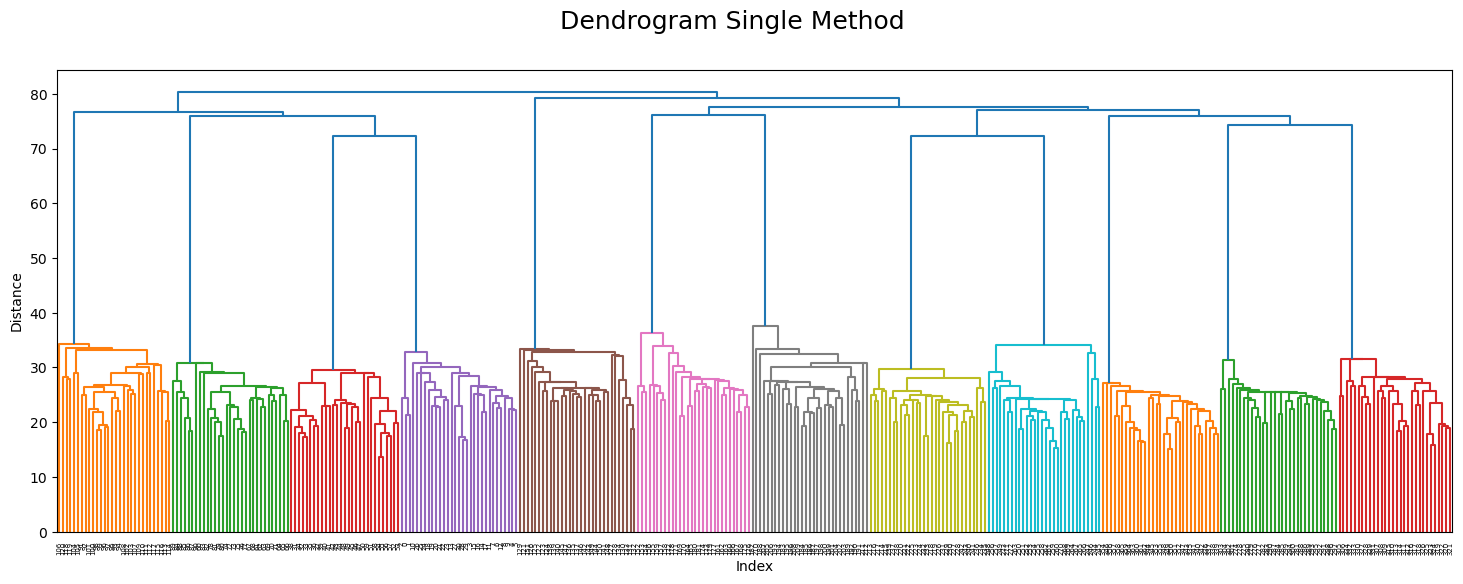

In [36]:
#run Dendrogram for unscaled set

distance_single = linkage(df1984,method="single")
plt.figure(figsize=(18,6))
dendrogram(distance_single, leaf_rotation=90)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("Dendrogram Single Method",fontsize=18)
plt.show()

#### too much data! will reduce?

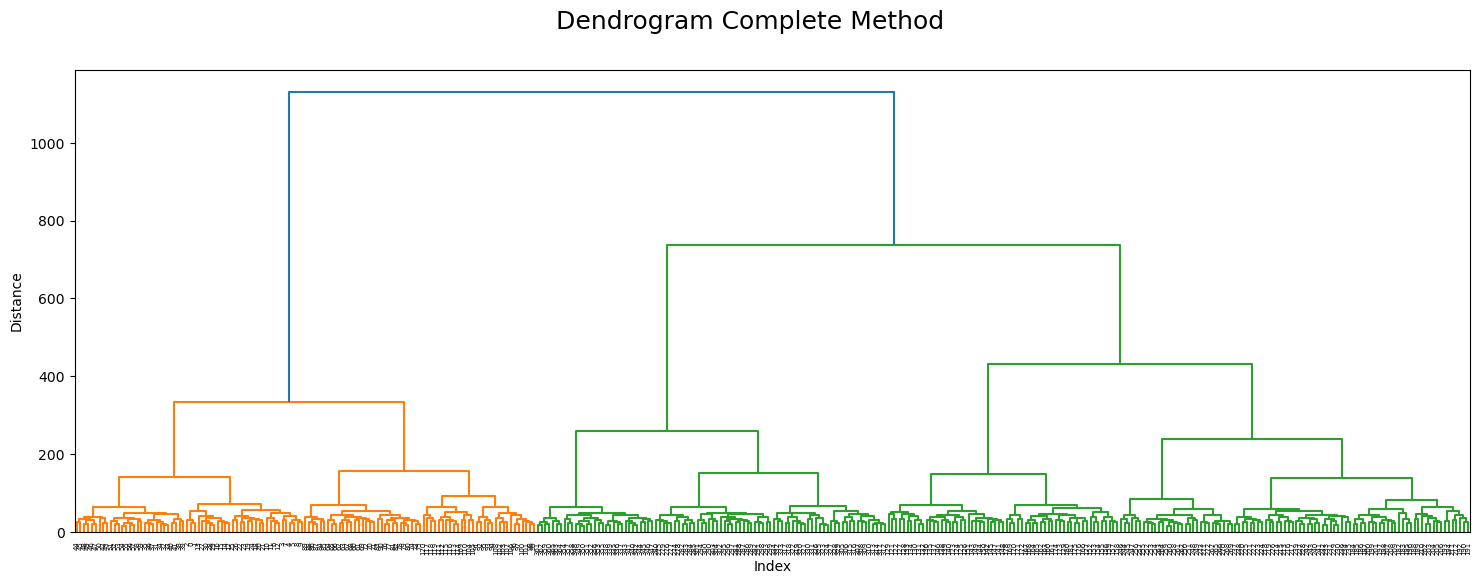

In [37]:
#run Dendrogram for unscaled set

distance_single = linkage(df1984,method="complete")
plt.figure(figsize=(18,6))
dendrogram(distance_single, leaf_rotation=90)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("Dendrogram Complete Method",fontsize=18)
plt.show()

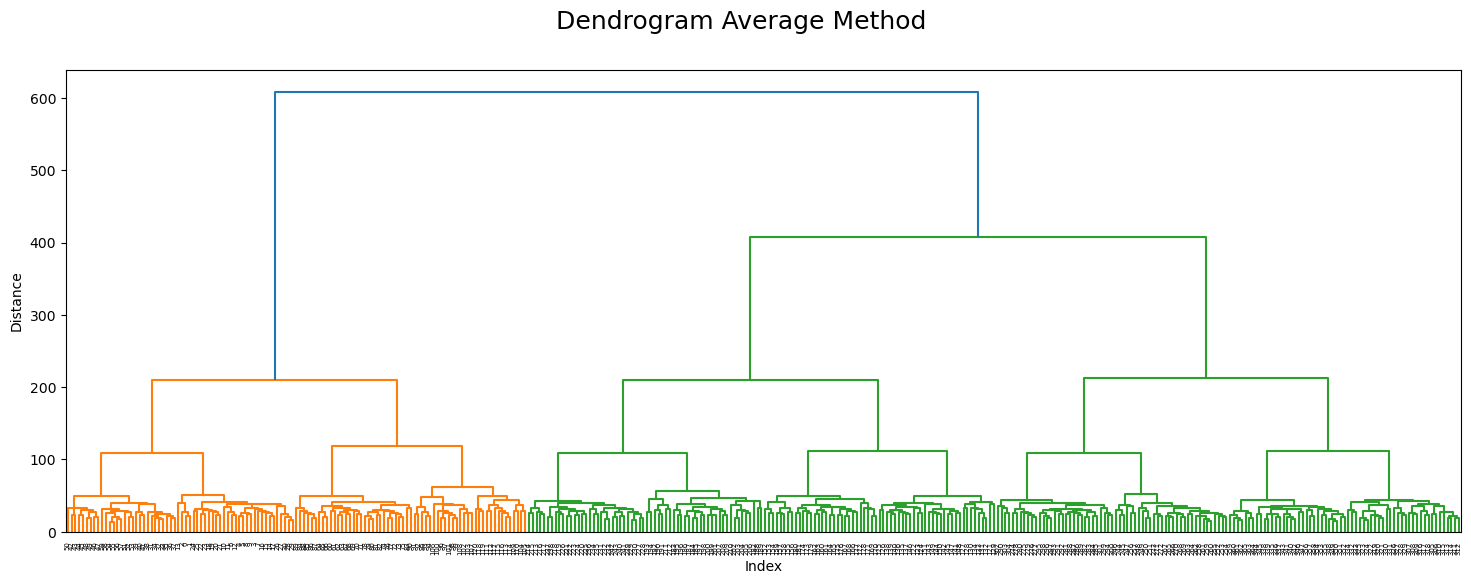

In [38]:
#run Dendrogram for unscaled set

distance_single = linkage(df1984,method="average")
plt.figure(figsize=(18,6))
dendrogram(distance_single, leaf_rotation=90)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("Dendrogram Average Method",fontsize=18)
plt.show()

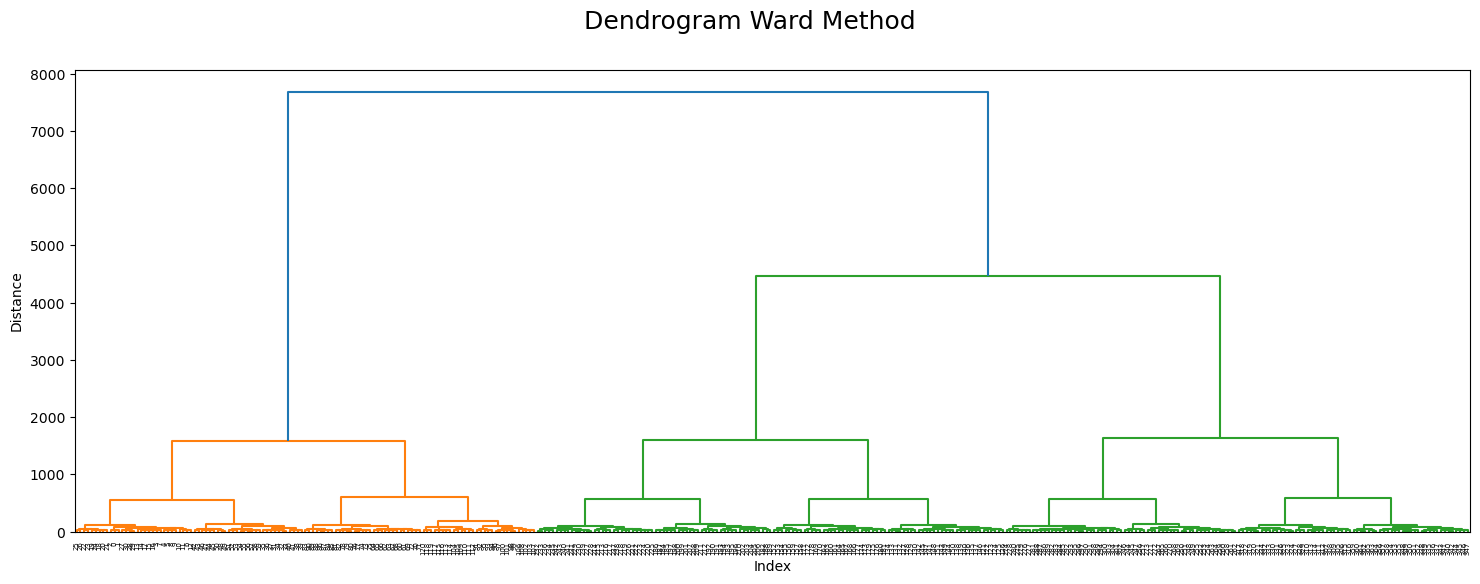

In [39]:
#run Dendrogram for unscaled set

distance_single = linkage(df1984,method="ward")
plt.figure(figsize=(18,6))
dendrogram(distance_single, leaf_rotation=90)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("Dendrogram Ward Method",fontsize=18)
plt.show()

#### 3. Dendrograms for scaled data

In [55]:
#Reduce your dataset to a single year
df31984 = df3[df3['DATE'].astype(str).str.contains('1984')] #<-----INSERT YEAR HERE
df31984

,DATE,MONTH,BASEL_cloud_cover,BASEL_wind_speed,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_snow_depth,BASEL_sunshine,...,VALENTIA_cloud_cover,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_snow_depth,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
8766,19840101,-1.599964,-1.001953,-0.02793,0.645423,1.450037,-0.832577,-0.445514,-0.179228,0.349774,...,0.783085,0.480538,-0.041247,-1.195214,0.562538,-0.024706,-1.039536,-0.457920,0.272755,-0.579689
8767,19840102,-1.599964,-0.586336,-0.02793,0.555086,1.037367,-0.843317,-0.445514,-0.179228,0.164190,...,0.169692,-0.363113,-1.271777,-1.195214,0.669056,-0.024706,-1.039536,-0.337751,-0.301123,-0.292110
8768,19840103,-1.599964,1.076130,-0.02793,0.193738,-0.873140,-1.251420,0.456318,-0.179228,-1.065304,...,0.169692,-1.769197,-0.833634,-1.112744,0.278489,-0.024706,-0.799250,-1.839859,-1.694827,-1.787524
8769,19840104,-1.599964,1.076130,-0.02793,0.464749,-0.032517,-1.229941,-0.425473,-0.179228,-1.042106,...,-0.443701,-1.066155,0.984194,-0.983148,0.053617,-0.024706,-0.709142,-1.239016,-1.722155,-1.154849
8770,19840105,-1.599964,-1.833187,-0.02793,-0.077273,1.465321,-0.886275,-0.425473,-0.179228,0.164190,...,0.783085,-0.503721,0.555373,-1.171651,-0.254103,-0.024706,-1.039536,-0.908552,-0.437761,-0.550931
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9127,19841227,1.594371,1.076130,-0.02793,1.639129,-0.277062,-1.240680,-0.225066,-0.179228,-1.065304,...,-0.443701,1.042971,0.024008,-1.159869,-0.443469,-0.024706,-1.039536,-1.659606,-2.241378,-1.298638
9128,19841228,1.594371,1.076130,-0.02793,1.639129,1.786286,-1.251420,-0.425473,-0.179228,-1.065304,...,1.396477,1.746013,0.760462,-1.195214,1.154307,-0.024706,-1.039536,-1.239016,-1.804137,-0.550931
9129,19841229,1.594371,1.076130,-0.02793,0.193738,2.657477,-1.305118,-0.445514,-0.179228,-1.065304,...,1.396477,2.449055,1.413015,-1.148088,-0.301444,-0.024706,-1.039536,0.112881,0.682668,-0.464657
9130,19841230,1.594371,-0.170720,-0.02793,-0.528957,2.978442,-1.025889,-0.445514,-0.179228,-0.531750,...,0.783085,2.027230,1.935058,-1.100962,-0.467139,-0.024706,-1.009500,-0.037330,0.245427,-0.320867


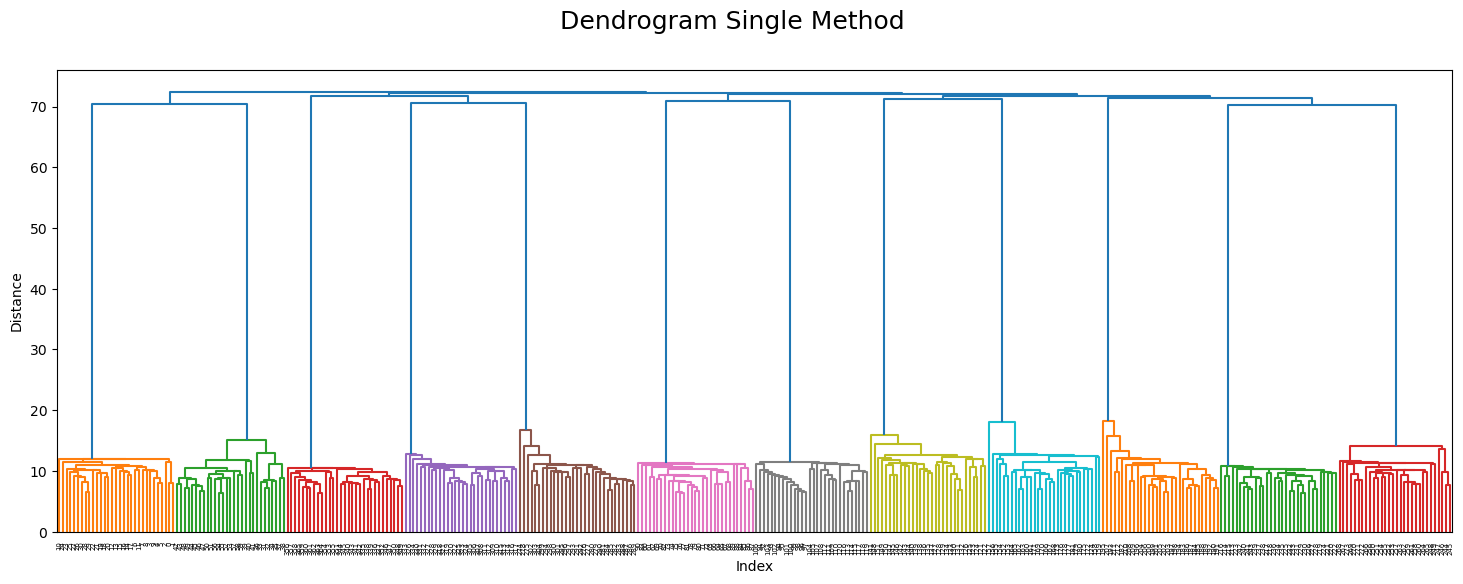

In [56]:
#run Dendrogram for scaled set

distance_single = linkage(df31984,method="single")
plt.figure(figsize=(18,6))
dendrogram(distance_single, leaf_rotation=90)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("Dendrogram Single Method",fontsize=18)
plt.show()

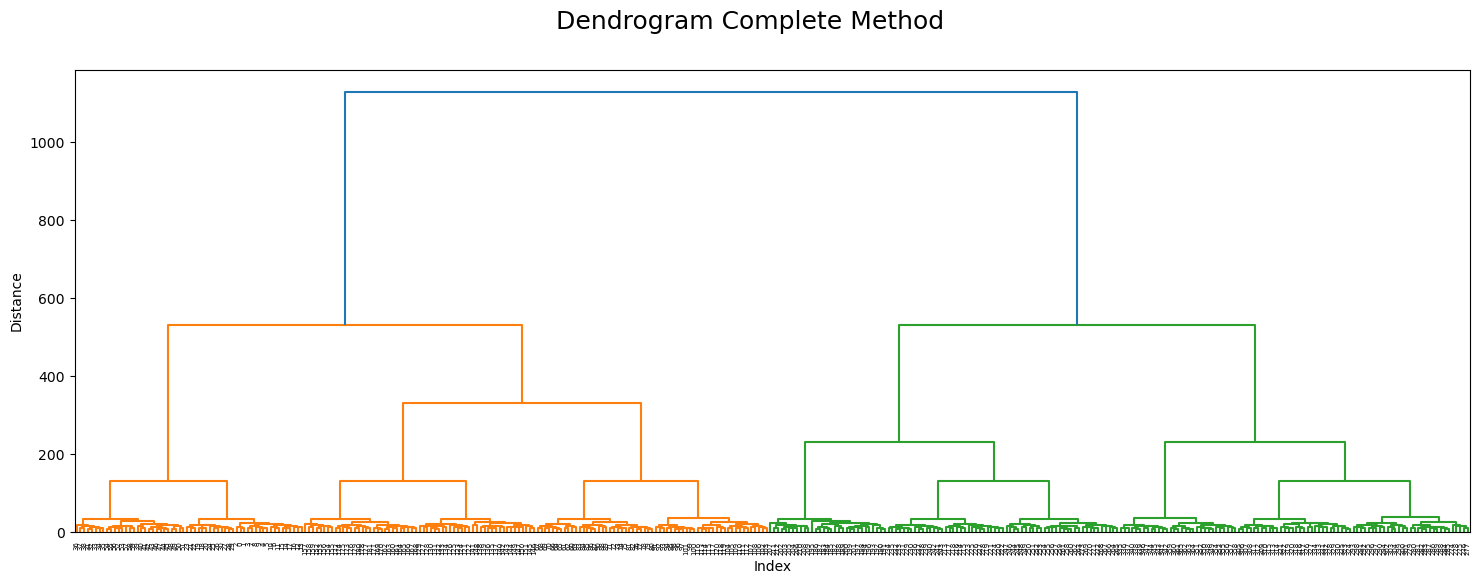

In [58]:
#run Dendrogram for scaled set

distance_single = linkage(df31984,method="complete")
plt.figure(figsize=(18,6))
dendrogram(distance_single, leaf_rotation=90)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("Dendrogram Complete Method",fontsize=18)
plt.show()

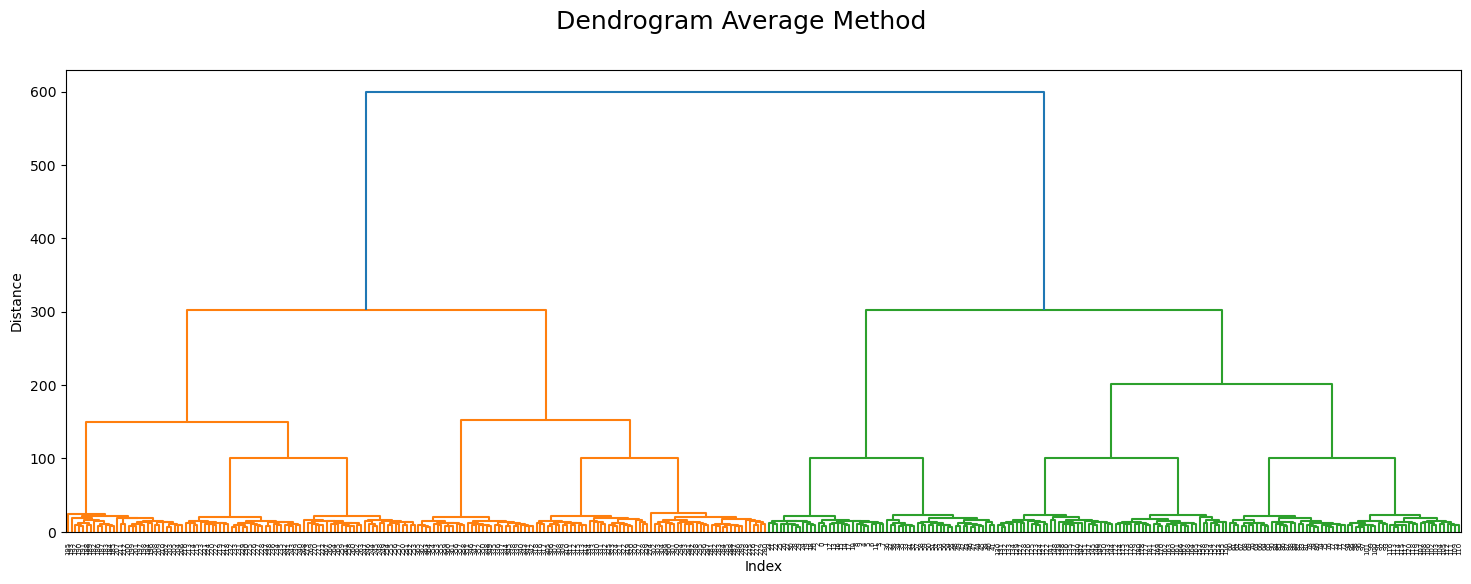

In [59]:
#run Dendrogram for scaled set

distance_single = linkage(df31984,method="average")
plt.figure(figsize=(18,6))
dendrogram(distance_single, leaf_rotation=90)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("Dendrogram Average Method",fontsize=18)
plt.show()

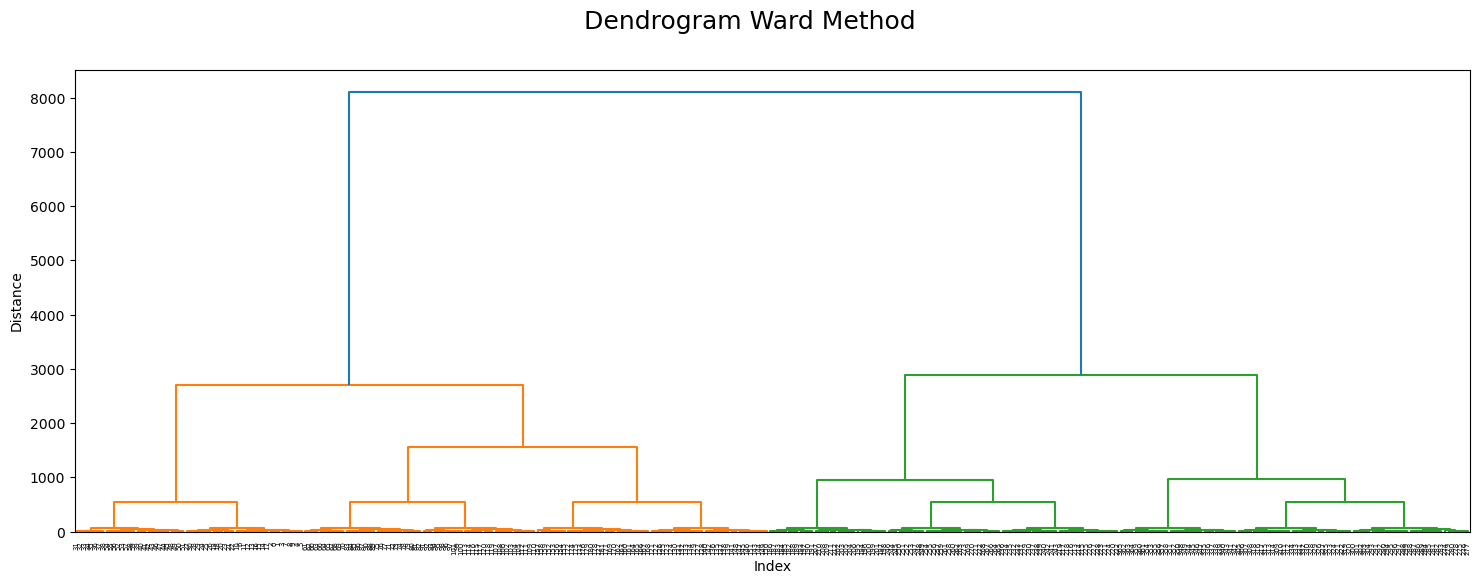

In [60]:
#run Dendrogram for scaled set

distance_single = linkage(df31984,method="ward")
plt.figure(figsize=(18,6))
dendrogram(distance_single, leaf_rotation=90)
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle("Dendrogram Ward Method",fontsize=18)
plt.show()